In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("webtraffic.csv")

# Suspicious Web Threat Interactions Data Set


# Question 1:

What is the correlation between bytes in bytes out?

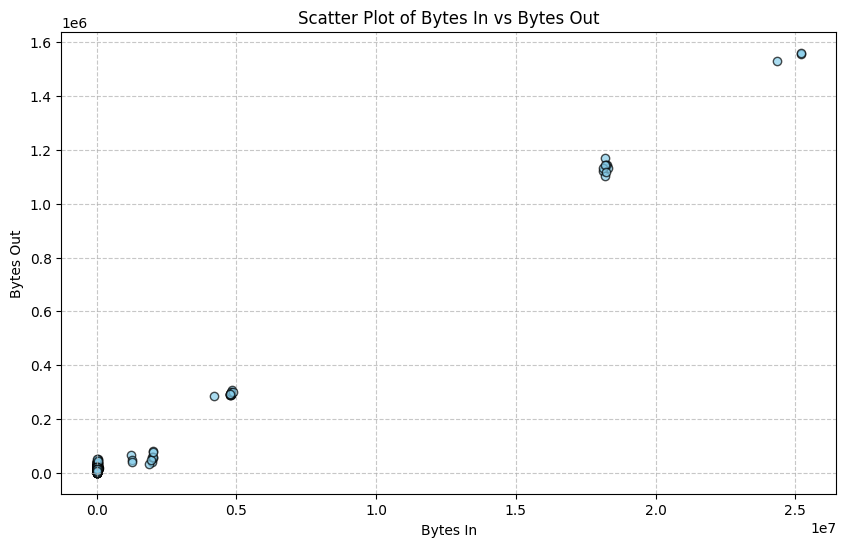

In [ ]:
# Find Average Bytes In and Bytes Out
average_bytes_in = df['bytes_in'].mean()
# Create Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['bytes_in'], df['bytes_out'], alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Scatter Plot of Bytes In vs Bytes Out')
plt.xlabel('Bytes In')
plt.ylabel('Bytes Out')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Question 1 analysis: 
As we can see there are 3 main clusters. Based on the infromation provided we can see that the areas for malicious correlate to bytes in and bytes out. 

# Question 2:
What is the average time of attacks each day?

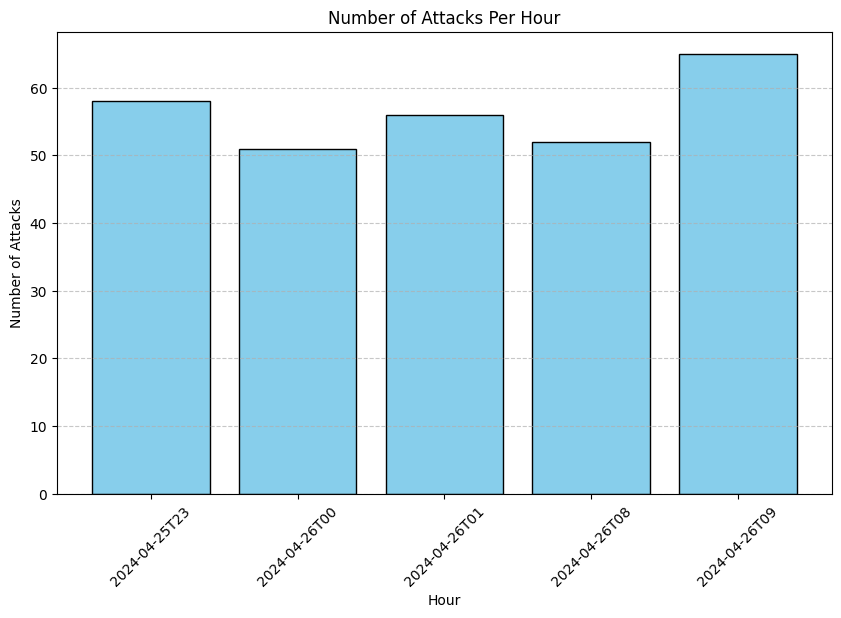

In [32]:
# Count the number of attacks per hour
times={}
for time in df['time']:
    time = time[:13]
    if time in times:
        times[time] += 1
    else:
        times[time] = 1
average_time_per_day = sum(times.values()) / len(times)
# Create Plot
plt.figure(figsize=(10, 6))
plt.bar(times.keys(), times.values(), color='skyblue', edgecolor='black')
plt.title('Number of Attacks Per Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Question 2 analysis:
Here we can see the ammount of attacks between 2300 and 0900, on two different days.

# 

# Question 3:

Out of the ip's given, which ones originate from the same attacker?

src_ip
165.225.209.4      29
165.225.26.101     28
155.91.45.242      28
136.226.67.101     28
147.161.131.1      21
165.225.240.79     18
136.226.77.103     17
147.161.161.82     16
165.225.212.255    15
94.188.248.74      14
136.226.64.114     13
165.225.33.6       12
165.225.213.7      11
136.226.80.97      11
165.225.8.79        6
192.241.230.19      2
65.49.1.69          2
Name: count, dtype: int64


Group 165.225: 21 IPs
['165.225.209.4', '165.225.26.101', '165.225.240.79', '165.225.212.255', '165.225.33.6', '165.225.213.7', '165.225.8.79', '165.225.209.4', '165.225.26.101', '165.225.240.79', '165.225.212.255', '165.225.33.6', '165.225.213.7', '165.225.8.79', '165.225.209.4', '165.225.26.101', '165.225.240.79', '165.225.212.255', '165.225.33.6', '165.225.213.7', '165.225.8.79']
Group 136.226: 12 IPs
['136.226.67.101', '136.226.77.103', '136.226.64.114', '136.226.80.97', '136.226.67.101', '136.226.77.103', '136.226.64.114', '136.226.80.97', '136.226.67.101', '136.226.77.103', '136

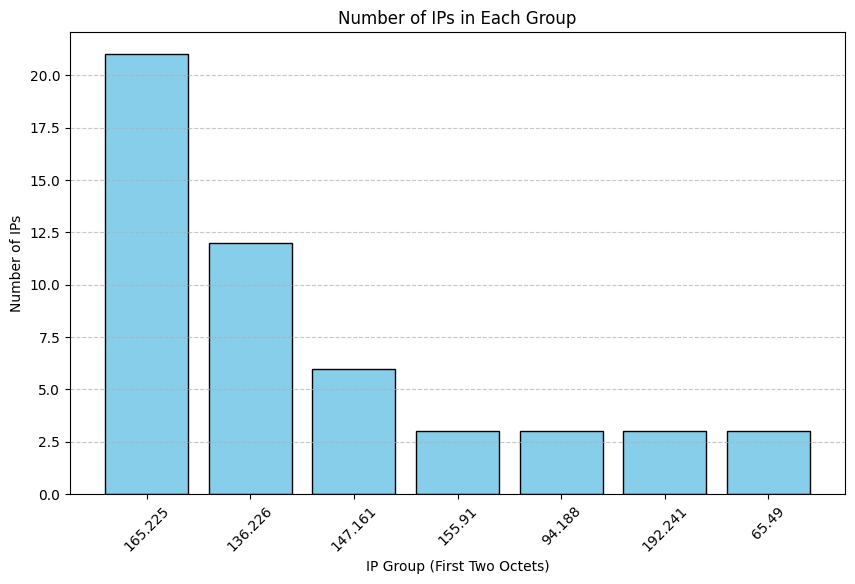

In [35]:
# Group by source IP and count occurrences
attacks_by_ip = df['src_ip'].value_counts()

# Filter IPs with more than one attack
same_ip_attacks = attacks_by_ip[attacks_by_ip > 1]
print(same_ip_attacks)

# Group IPs by the first two octets
for ip in same_ip_attacks.index:
    first_two_octets = '.'.join(ip.split('.')[:2])
    grouped_ips[first_two_octets].append(ip)

# Sort groups by the number of IPs in each group
sorted_groups = sorted(grouped_ips.items(), key=lambda x: len(x[1]), reverse=True)

print()
print()

# Display the sorted groups
for group, ips in sorted_groups:
    print(f"Group {group}: {len(ips)} IPs")
    print(ips)
    
 # Visualize the number of IPs in each group
group_names = [group for group, _ in sorted_groups]
group_sizes = [len(ips) for _, ips in sorted_groups]
plt.figure(figsize=(10, 6))
plt.bar(group_names, group_sizes, color='skyblue', edgecolor='black')
plt.title('Number of IPs in Each Group')
plt.xlabel('IP Group (First Two Octets)')
plt.ylabel('Number of IPs')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



# Question 3 Analysis:

Here we can see which IP's were used and the number of times IP's were used.

# Question 4:
What percentage of attacks were carried out by each country?

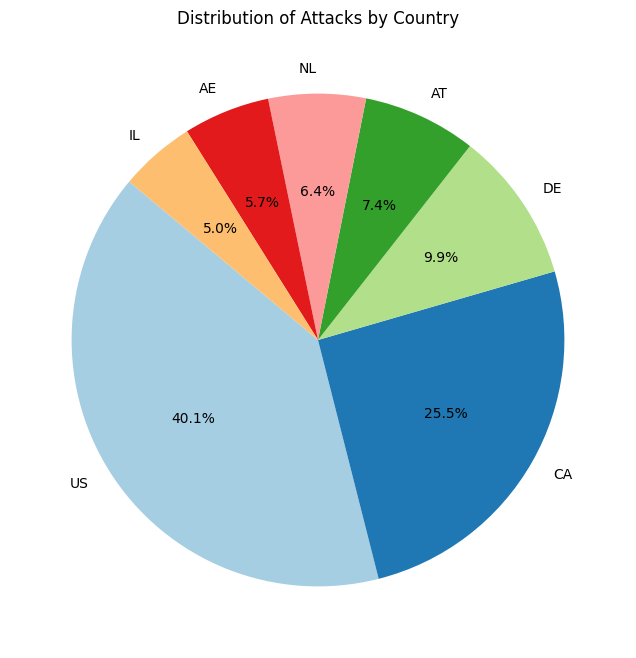

In [29]:

# Count the number of attacks per country
country_counts = df['src_ip_country_code'].value_counts()

# Plot a pie chart
plt.figure(figsize=(8, 8))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Attacks by Country')
plt.show()

# Question 4 Analysis:
Here we can see each country involved and what percentage they were responsible for attacks.